# Redes neuronales
## Emmanuel Juda Rodriguez Nachez

En esta sesión tuvimos una introducción a las redes neuronales

En este notebook se hara:
-Una red neuronal de una capas con una funcion lineal y una funcion de activacion sigmoide
-Una red neuronal con dos capas, ambas lineales pero una con una funcion relu y otra con una sigmoide 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

## Cargado de datos

Como primera parte se preparan los datos de entrenamiento y prueba, esto es importante pues cada imagen debe llevar las mismas caracterizticas y estar optimizada para tabajar en nuestra red

In [12]:
# Cargamos la imagenes del conjunto de entrenamiento
cats_train = []
dogs_train = []
for i in range(1000):
    img = Image.open('archive/test_set/cats/cat.'+ str(4001+i)+'.jpg')
    cats_train.append(img.resize((64, 64)))
    img = Image.open('archive/test_set/dogs/dog.'+ str(4001+i)+'.jpg')
    dogs_train.append(img.resize((64, 64)))

In [162]:
#Cargamos las imagenes del conjunto de prueba
cats_test = []
dogs_test = []
for i in range(1000):
    img = Image.open('archive/training_set/cats/cat.'+ str(1+i)+'.jpg')
    cats_test.append(img.resize((64, 64)))
    img = Image.open('archive/training_set/dogs/dog.'+ str(1+i)+'.jpg')
    dogs_test.append(img.resize((64, 64)))

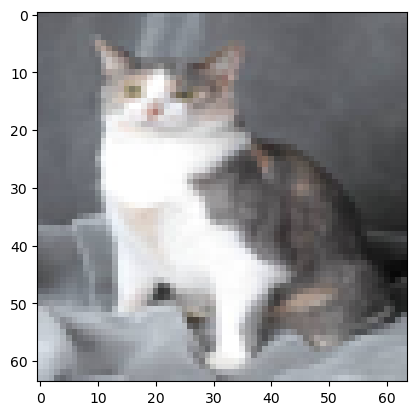

In [13]:
#Probamos que las imagenes sean como deseamos
plt.imshow(cats_train[40])

In [14]:
#Mezclamos y acomodamos los datos de entrenamiento en forma de matriz, ademas de normalizar los datos
datos = [(x, 1) for x in cats_train] + [(x, 0) for x in dogs_train]

# Mezclar
random.shuffle(datos)

# Separar nuevamente
X_train = [x for x, origen in datos]
Y_train = [origen for x, origen in datos]

Y_train = np.array(Y_train)
X_train = np.array(X_train).reshape(len(Y_train),-1)/255
X_trainT = X_train.T

In [163]:
#Mezclamos y acomodamos los datos de entrenamiento en forma de matriz, ademas de normalizar los datos
datos = [(x, 1) for x in cats_test] + [(x, 0) for x in dogs_test]

# Mezclar
random.shuffle(datos)

# Separar nuevamente
X_test = [x for x, origen in datos]
Y_test = [origen for x, origen in datos]

Y_test = np.array(Y_test)
X_test = np.array(X_test).reshape(len(Y_test),-1)/255
X_testT = X_test.T

In [165]:
#Eliminamos estos que solo gastarian memoria
del dogs_train, cats_train
del dogs_test, cats_test

## Red de una capa

Esta red sera de una capa con una funcion lineal y una funcion de activación sigmoide

In [179]:
# Creamos las funciones necesarias para el codigo

#Funcion lineal
def lin(m,b,xT):
    return m@xT + b

#Funcion sigmoide
def sig(z):
    return 1/(1+np.exp(-z))

#Esta es una capa de una lineal con una sigmoide de activacion
def layerlin(m,b,xT):
    return sig(lin(m,b,xT))

#En esta hacemos un criterio de que si es mayor a 0.5 se vuelve 1 y en el otro caso 0, esto para la clasificacion binaria
def des(a):
    return (a > 0.5).astype(int)

#Aqui hacemos una red de una neurona con una funcion lineal y una funcion de activacion sigmoide
def red(weights, xT):
    m, b = weights
    layer1 = layerlin(m,b,xT)
    return layer1

#Aqui hacemos el calculo de la funcion de costo con los datos predichos y los reales
def cost_simple(y_real, y_train):
    argu = y_real*np.log(y_train)+(1-y_real)*np.log(1-y_train)
    
    return (-1/len(y_real) * np.sum(argu))

#Aqui calculamos la funcion de activacion con los pesos como argumento
def cost_weights(weights, xT, y_real):
    argu = cost_weigths_arg(weights, xT, y_real)
    
    return (-1/len(y_real) * np.sum(argu))

#Aqui se calcula el argumento de la suma en la funcion costo
def cost_weights_arg(weights, xT, y_real):
    m, b = weights
    y_train = layerlin(m,b,xT)
    argu = y_real*np.log(y_train)+(1-y_real)*np.log(1-y_train)
    return argu

#derivada respecto a m de la funcion costo de una capa lineal sigmoide
def der_cost_m(weights, xT, y_real):
    m, b = weights
    y_weights = layerlin(m,b,xT)

    deriv = (1/len(y_real))* xT @ (y_weights-y_real)
    return deriv
    
#derivada respecto a b de la funcion costo de una capa lineal sigmoide
def der_cost_b(weights, xT, y_real):
    m, b = weights
    y_weights = layerlin(m,b,xT)

    deriv = (1/len(y_real))*np.sum(y_weights-y_real)
    return deriv

#Actualizacion de pesos de la red de una capa lineal sigmoide
def update_weights(weights, alpha, xT, y_real):
    m, b = weights
    dercostm = der_cost_m(weights, xT, y_real)
    dercostb = der_cost_b(weights, xT, y_real)
    return m - alpha*dercostm , b - alpha*dercostb

In [180]:
#inicializamos los pesos
m=np.zeros(64*64*3)
b=0.0

In [148]:
#Entrenamiento de la red
alpha = 0.01
cost = []
for i in range(1000):
    m,b = update_weights((m,b), 0.001, X_trainT, Y_train)
    cost.append(cost_weights((m,b), X_trainT, Y_train))

In [176]:
Y_train_predict = des(red((m,b), X_trainT))
correcto = sum(x == y for x, y in zip(Y_train_predict, Y_train))
print('La red tiene un porcentaje de aprovación en los datos de entrenamiento de: \n' + str((correcto/len(Y_train))*100) + '%')

La red tiene un porcentaje de aprovación en los datos de entrenamiento de: 
64.3%


In [177]:
Y_test_predict = des(red((m,b), X_testT))
correcto = sum(x == y for x, y in zip(Y_test_predict, Y_test))
print('La red tiene un porcentaje de aprovación en los datos de prueba de: \n' + str((correcto/len(Y_test))*100) + '%')

La red tiene un porcentaje de aprovación en los datos de prueba de: 
57.65%


0.0

## Red de dos capas

Esta función tendra dos capas, ambas con una función lineal, pero la primera con una función de activación leaky relu y otra con la función de activación sigmoide

In [288]:
#Definiremos algunas funciones auxiliares

def leaky_relu(z):
    return np.where(z > 0, z, 0.01 * z)

def d_leaky_relu(z):
    return np.where(z > 0, 1.0, 0.01)

def red2(weights,xT):
    w1,b1,w2,b2 = weights
    l1 = leaky_relu(lin(w1,b1,xT))
    l2 = sig(w2*l1 + b2)
    return l2

#Aqui calculamos la funcion de activacion con los pesos como argumento
def cost_weights2(weights, xT, y_real):
    argu = cost_weights_arg2(weights, xT, y_real)
    
    return (-1/len(y_real) * np.sum(argu))

#Aqui se calcula el argumento de la suma en la funcion costo
def cost_weights_arg2(weights, xT, y_real):
    w1,b1,w2,b2 = weights
    l1 = leaky_relu(lin(w1,b1,xT))
    y_train = sig(w2*l1 + b2)
    argu = y_real*np.log(y_train)+(1-y_real)*np.log(1-y_train)
    return argu

def der_cost_w1(d1, xT):
    return (1/len(xT)) * xT@d1
    
def der_cost_w2(d2, a1):
    return (1/len(a1)) * d2@a1

def der_cost_b1(d1):
    return np.sum(d1)/len(d1)

def der_cost_b2(d2):
    return np.sum(d2)/len(d2)

def update_weights2(weights, alpha, xT, y_real):
    w1,b1,w2,b2 = weights

    z1 = lin(w1,b1,xT)
    a1 = leaky_relu(z1)

    d2 = red2(weights, xT) - y_real
    d1 = w2 * d2 * d_leaky_relu(z1)
    
    dercostw1 = der_cost_w1(d1, xT)
    dercostw2 = der_cost_w2(d2, a1)
    dercostb1 = der_cost_b1(d1)
    dercostb2 = der_cost_b2(d2)
    return w1 - alpha*dercostw1, w2 - alpha*dercostw2, b1 - alpha*dercostb1, b2 - alpha*dercostb2

In [401]:
#inicializamos los pesos
w1=np.random.rand(12288)
b1=0.0
w2=np.random.rand()
b2=0.0

In [402]:
#Entrenamiento de la red
cost = []
for i in range(1000):
    w1,b1,w2,b2 = update_weights2((w1,b1,w2,b2), 0.01, X_trainT, Y_train)
    cost.append(cost_weights2((w1,b1,w2,b2), X_trainT, Y_train))

/var/folders/w2/bc_hd1792ng0j46hmt8zbzcr0000gp/T/ipykernel_28971/2108897672.py:9: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))
/var/folders/w2/bc_hd1792ng0j46hmt8zbzcr0000gp/T/ipykernel_28971/2821914577.py:26: RuntimeWarning: divide by zero encountered in log
  argu = y_real*np.log(y_train)+(1-y_real)*np.log(1-y_train)
/var/folders/w2/bc_hd1792ng0j46hmt8zbzcr0000gp/T/ipykernel_28971/2821914577.py:26: RuntimeWarning: invalid value encountered in multiply
  argu = y_real*np.log(y_train)+(1-y_real)*np.log(1-y_train)


In [412]:
Y_train_predict2 = des(red2((w1,b1,w2,b2), X_trainT))
correcto = sum(x == y for x, y in zip(Y_train_predict2, Y_train))
print('La red 2 tiene un porcentaje de aprovación en los datos de entrenamiento de: \n' + str((correcto/len(Y_train))*100) + '%')

La red 2 tiene un porcentaje de aprovación en los datos de entrenamiento de: 
50.8%


In [413]:
Y_test_predict2 = des(red2((w1,b1,w2,b2), X_testT))
correcto = sum(x == y for x, y in zip(Y_test_predict2, Y_test))
print('La red 2 tiene un porcentaje de aprovación en los datos de prueba de: \n' + str((correcto/len(Y_test))*100) + '%')

La red 2 tiene un porcentaje de aprovación en los datos de prueba de: 
51.0%


En este caso no encontramos una mejoria, esto puede deberse a que toda la informacion de la imagen se condensa en una capa y despues la segunda capa tiene mas poder para decidir si es o no un gato, pero al no tener informacion suficiente no se puede entrenar de forma adecuada. Para que mejore, es necesario agregar mas neuronas a la capa oculta y que estas entregen mas informacion a la ultima capa.